# Information of the notebook
---

This notebook is prepared for the **Capstone BBO Stage 1** Project.

The aim of the Capstone BBO Stage 1 is to build the skills and habits required for the BBO challenge in Stage 2.

For this experiment, **House Prices - Advanced Regression Techniques, link from Kaggle**  is chosen from Kaggle.

(https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview Links to an external site.)

This notebook contains the prediction for house prices using **RandomForestRegressor**. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [3]:
# reading/assigning the training dataset
df = pd.read_csv('train.csv')

# identifying the contributing factors
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
print(df['SalePrice'].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

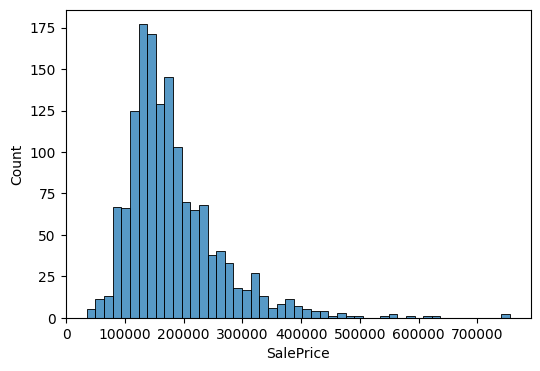

In [7]:
# house price distribution

plt.figure(figsize=(6, 4))
sns.histplot(df['SalePrice'])

In [8]:
# Select int64 dtype parameters for prediction
X = df[['MSSubClass', 
'LotArea', 
'OverallQual', 
'OverallCond', 
'YearBuilt', 
'YearRemodAdd', 
'BsmtFinSF1', 
'BsmtFinSF2', 
'BsmtUnfSF', 
'TotalBsmtSF', 
'1stFlrSF', 
'2ndFlrSF', 
'LowQualFinSF', 
'GrLivArea', 
'BsmtFullBath', 
'BsmtHalfBath', 
'FullBath', 
'HalfBath', 
'BedroomAbvGr', 
'KitchenAbvGr', 
'TotRmsAbvGrd', 
'Fireplaces', 
'GarageCars', 
'GarageArea', 
'WoodDeckSF', 
'OpenPorchSF', 
'EnclosedPorch', 
'3SsnPorch', 
'ScreenPorch', 
'PoolArea', 
'MiscVal', 
'MoSold', 
'YrSold',]]

In [9]:
X

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,8450,7,5,2003,2003,706,0,150,856,...,548,0,61,0,0,0,0,0,2,2008
1,20,9600,6,8,1976,1976,978,0,284,1262,...,460,298,0,0,0,0,0,0,5,2007
2,60,11250,7,5,2001,2002,486,0,434,920,...,608,0,42,0,0,0,0,0,9,2008
3,70,9550,7,5,1915,1970,216,0,540,756,...,642,0,35,272,0,0,0,0,2,2006
4,60,14260,8,5,2000,2000,655,0,490,1145,...,836,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,7917,6,5,1999,2000,0,0,953,953,...,460,0,40,0,0,0,0,0,8,2007
1456,20,13175,6,6,1978,1988,790,163,589,1542,...,500,349,0,0,0,0,0,0,2,2010
1457,70,9042,7,9,1941,2006,275,0,877,1152,...,252,0,60,0,0,0,0,2500,5,2010
1458,20,9717,5,6,1950,1996,49,1029,0,1078,...,240,366,0,112,0,0,0,0,4,2010


In [10]:
# Define the target variable, Sale Price

Y = df['SalePrice']
Y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [11]:
# train test split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)

In [12]:
# Use RandomForestRegressor

rf_model = RandomForestRegressor(random_state = 1)
rf_model.fit(X_train,Y_train)
rf_val_predictions = rf_model.predict(X_test)

pred = rf_model.predict(X_test)

RMSE_RF = math.sqrt(mean_squared_error(pred, Y_test))

print("Random Forest Regressor Model RMSE: ", RMSE_RF)

Random Forest Regressor Model RMSE:  29587.905902972572


<div class="alert-warning">
the RMSE for Random Forest is pretty high.
</div>

<div class="alert-info">
Neglecting those features (object type) costs poor RMSE
</div>

In [13]:
# reset the dataset from csv

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [14]:
# define train, target and test

target = train['SalePrice']
test_ids = test['Id']

train = train.drop(['SalePrice', 'Id'], axis = 1)
test = test.drop(['Id'], axis = 1)

In [15]:
# check dataset for categorical with none

dataset = pd.concat([train, test], axis = 0)
dataset.select_dtypes('object').loc[:, dataset.isna().sum()> 0].columns
categorical_with_none = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature',   
]

categorical = dataset.select_dtypes('object').loc[:, dataset.isna().sum() > 0].columns

C:\Users\May Zune\AppData\Local\Temp\ipykernel_19708\1673089354.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dataset.select_dtypes('object').loc[:, dataset.isna().sum()> 0].columns
C:\Users\May Zune\AppData\Local\Temp\ipykernel_19708\1673089354.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyd

In [16]:
# check column with categorical none

for col in categorical_with_none:
    dataset[col] = dataset[col].fillna('None')
for col in categorical:
    mod = dataset[col].mode()[0]
    dataset[col] = dataset[col].fillna(mod)

In [17]:
# selecting the columns

dataset.select_dtypes('object').loc[:, dataset.isna().sum()> 0].columns
dataset.select_dtypes(np.number).loc[:, dataset.isna().sum() > 0].columns

C:\Users\May Zune\AppData\Local\Temp\ipykernel_19708\552138160.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dataset.select_dtypes('object').loc[:, dataset.isna().sum()> 0].columns


Index(['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea'],
      dtype='str')

In [18]:
# defining fill with knn method

def FillWithKNN(dataset, ToFill):
    df = dataset.copy()

    numeric_df = df.select_dtypes(np.number)
    non_na_columns = numeric_df.loc[:, numeric_df.isna().sum() == 0].columns
    y_train = numeric_df.loc[numeric_df[ToFill].isna() == False, ToFill]
    X_train = numeric_df.loc[numeric_df[ToFill].isna() == False, non_na_columns]
    X_test = numeric_df.loc[numeric_df[ToFill].isna() == True, non_na_columns]
    
    knn = KNeighborsRegressor(n_neighbors = 10)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    df.loc[df[ToFill].isna() == True, ToFill] = y_pred
    return df

In [19]:
# using KNN to fill dataset

na_columns = dataset.columns[(dataset.isna().sum()) > 0]
for column in na_columns:
    dataset = FillWithKNN(dataset, column)

In [20]:
# define train and test sets, consider full data

train = dataset.iloc[:train.shape[0], :].copy()
test = dataset.iloc[train.shape[0]:, :].copy()
full = [train, test]
for ds in full:
    categories = ds.select_dtypes('object').columns
    for column in categories:
        dic = pd.concat([ds[column], target], axis = 1).groupby(column).mean().sort_values(by = 'SalePrice')
        mp = {}
        p = 0
        for it in dic.index:
            mp[it] = p
            p += 1
        ds[column] = ds[column].map(mp)
    categories = ds.select_dtypes('object').columns

C:\Users\May Zune\AppData\Local\Temp\ipykernel_19708\1739286313.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = ds.select_dtypes('object').columns
C:\Users\May Zune\AppData\Local\Temp\ipykernel_19708\1739286313.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m

In [21]:
# normalization of data using StandardScaler

X = train.copy()
y = target.copy()
X = StandardScaler().fit_transform(X)
test = StandardScaler().fit_transform(test)

In [22]:
# splitting data 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 8, shuffle = True)

# verifying the shape
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1314, 79), (146, 79), (1314,), (146,))

In [23]:
# training for the improved model using RandomForestRegressor

RFreg = RandomForestRegressor(n_estimators = 100)
RFreg.fit(X_train, y_train)
pred = RFreg.predict(X_test)
print("New RF RMSE: ", math.sqrt(mean_squared_error(pred, y_test)))

New RF RMSE:  19398.899843158455


<div class="alert-danger">
Switching the dataset affects RMSE values, but the RandomForestRegressor for this study perform poorly.
</div>

In [24]:
# Prepare dataframe for predicted values

y_pred = RFreg.predict(test)
submission = pd.DataFrame({
        "Id": range(1461, 2920),
        "SalePrice": y_pred
    })

submission

,Id,SalePrice
0,1461,134910.00
1,1462,172212.08
2,1463,187082.57
3,1464,188709.66
4,1465,198136.24
...,...,...
1454,2915,88330.93
1455,2916,90354.50
1456,2917,166152.89
1457,2918,132999.00


# Compare with the Sample submission

In [25]:
# Import the reference sample submission CSV 

sample_submission  = pd.read_csv('sample_submission.csv')

In [26]:
sample_submission.head(3)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570


In [27]:
sample_submissionX = sample_submission.rename(columns={"SalePrice": "SalePrice_Sample"})

In [28]:
df_merged = submission.merge(sample_submissionX, on='Id')

In [29]:
df_merged.head(2)

,Id,SalePrice,SalePrice_Sample
0,1461,134910.00,169277.052498
1,1462,172212.08,187758.393989


In [30]:
df_merged["difference_percent"] = ((df_merged["SalePrice"] - df_merged["SalePrice_Sample"])/ df_merged["SalePrice"])*100

In [31]:
df_merged.head(2)

,Id,SalePrice,SalePrice_Sample,difference_percent
0,1461,134910.00,169277.052498,-25.474059
1,1462,172212.08,187758.393989,-9.027424


In [32]:
df_merged.describe()

,Id,SalePrice,SalePrice_Sample,difference_percent
count,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,180781.855483,179183.918243,-9.292065
std,421.321334,65374.472116,16518.303051,32.372485
min,1461.000000,60556.140000,135751.318893,-195.183199
25%,1825.500000,137712.765000,168703.011202,-28.263122
50%,2190.000000,165958.000000,179208.665698,-8.230412
75%,2554.500000,202873.765000,186789.409363,10.195995
max,2919.000000,526930.360000,281643.976117,62.032010


<div class="alert-warning">
RandomForestRegressor underestimates the sale prices
</div>